# Telecom Customer Churn: End-to-End Data Science Project

**Goal:** Predict which telecom customers will churn, and find out *what* drives churn.

**Dataset:** `telecom_churn.csv` (raw file, ~243,553 customers, 14 columns).

| Column | Meaning |
|---|---|
| `customer_id` | Unique customer ID |
| `telecom_partner` | Operator (Airtel, Reliance Jio, Vodafone, BSNL) |
| `gender`, `age`, `num_dependents`, `estimated_salary` | Customer profile |
| `state`, `city`, `pincode` | Location |
| `date_of_registration` | Date the customer joined |
| `calls_made`, `sms_sent`, `data_used` | Usage |
| `churn` | **Target** (1 = churned, 0 = retained) |

---

## Table of Contents
1. Setup and Configuration
2. Load Data
3. Data Quality Audit and Cleaning
4. Feature Engineering
5. Exploratory Data Analysis (EDA)
6. Statistical Testing (with multiple-testing correction)
7. Train / Test Split
8. Preprocessing Pipelines
9. Baselines
10. Model Training and Evaluation
11. Cross-Validation
12. Hyperparameter Tuning
13. Sanity Checks: is there any real signal?
14. Conclusion and Next Steps

---

## TL;DR (results from the full-data run)
- Every model, including tuned Random Forest, scored **ROC-AUC ~ 0.50**, the same as a dummy classifier.
- Cross-validation confirmed this is stable (0.500 to 0.502 across folds).
- Medians, correlations and churn rates are almost identical for churned and retained customers.
- State, city and pincode do not agree with each other (e.g. Karnataka with Kolkata), which suggests the data is synthetic or randomly generated.
- **Conclusion:** with these features, individual churn cannot be predicted. The next step is better data (contract type, monthly charges, complaints, network quality), not more modelling.

> The cells below recompute all of this. If your numbers differ, update Section 14.

## 1. Setup and Configuration
All settings are in one place. To reuse this notebook on another dataset, change `DATA_PATH`, `TARGET` and the feature lists in Section 4.

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [3]:
# ---------------- Configuration ----------------
DATA_PATH     = "telecom_churn.csv"   # raw file (before cleaning)
TARGET        = "churn"
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
CV_FOLDS      = 5
TUNING_SAMPLE = 60_000                # rows used for the (slow) hyperparameter search
ALPHA         = 0.05                  # significance level for statistical tests

## 2. Load Data

In [6]:
df = pd.read_csv("telecom_churn.csv")

required = ["customer_id", "telecom_partner", "gender", "age", "state", "city", "pincode",
            "date_of_registration", "num_dependents", "estimated_salary",
            "calls_made", "sms_sent", "data_used", TARGET]
missing_cols = [c for c in required if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 243,553 | Columns: 14


,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   customer_id           243553 non-null  int64
 1   telecom_partner       243553 non-null  str  
 2   gender                243553 non-null  str  
 3   age                   243553 non-null  int64
 4   state                 243553 non-null  str  
 5   city                  243553 non-null  str  
 6   pincode               243553 non-null  int64
 7   date_of_registration  243553 non-null  str  
 8   num_dependents        243553 non-null  int64
 9   estimated_salary      243553 non-null  int64
 10  calls_made            243553 non-null  int64
 11  sms_sent              243553 non-null  int64
 12  data_used             243553 non-null  int64
 13  churn                 243553 non-null  int64
dtypes: int64(9), str(5)
memory usage: 26.0 MB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,"243,553.0000","121,777.0000","70,307.8394",1.0000,"60,889.0000","121,777.0000","182,665.0000","243,553.0000"
age,"243,553.0000",46.0776,16.4440,18.0000,32.0000,46.0000,60.0000,74.0000
pincode,"243,553.0000","549,501.2705","259,808.8606","100,006.0000","324,586.0000","548,112.0000","774,994.0000","999,987.0000"
num_dependents,"243,553.0000",1.9975,1.4149,0.0000,1.0000,2.0000,3.0000,4.0000
estimated_salary,"243,553.0000","85,021.1378","37,508.9632","20,000.0000","52,585.0000","84,990.0000","117,488.0000","149,999.0000"
calls_made,"243,553.0000",49.0105,29.4536,-10.0000,24.0000,49.0000,74.0000,108.0000
sms_sent,"243,553.0000",23.9454,14.7336,-5.0000,11.0000,24.0000,36.0000,53.0000
data_used,"243,553.0000","4,993.1860","2,942.0195",-987.0000,"2,490.0000","4,987.0000","7,493.0000","10,991.0000"
churn,"243,553.0000",0.2005,0.4004,0.0000,0.0000,0.0000,0.0000,1.0000


## 3. Data Quality Audit and Cleaning
Only **row-level, label-independent** fixes are done here (types, invalid values). Anything that learns from the data, such as filling with a median, is done later *inside the pipeline* so that test data never influences training.

### 3.1 Duplicates, missing values, data types

In [9]:
audit = pd.DataFrame({
    "dtype":   df.dtypes.astype(str),
    "missing": df.isnull().sum(),
    "unique":  df.nunique(),
})
print("Duplicate rows       :", df.duplicated().sum())
print("Duplicate customer_id:", df["customer_id"].duplicated().sum())
audit

Duplicate rows       : 0
Duplicate customer_id: 0


,dtype,missing,unique
customer_id,int64,0,243553
telecom_partner,str,0,4
gender,str,0,2
age,int64,0,57
state,str,0,28
city,str,0,6
pincode,int64,0,213442
date_of_registration,str,0,1220
num_dependents,int64,0,5
estimated_salary,int64,0,110032


In [10]:
# Registration date -> datetime
df["date_of_registration"] = pd.to_datetime(df["date_of_registration"], errors="coerce")

print("Unparseable dates:", df["date_of_registration"].isna().sum())
print("Date range       :", df["date_of_registration"].min().date(), "to", df["date_of_registration"].max().date())

Unparseable dates: 0
Date range       : 2020-01-01 to 2023-05-04


### 3.2 Range checks (impossible values)

In [11]:
numeric_raw = ["age", "num_dependents", "estimated_salary", "calls_made", "sms_sent", "data_used"]
ranges = df[numeric_raw].agg(["min", "max"]).T
ranges["negative_rows"] = (df[numeric_raw] < 0).sum()
ranges

,min,max,negative_rows
age,18,74,0
num_dependents,0,4,0
estimated_salary,20000,149999,0
calls_made,-10,108,6713
sms_sent,-5,53,7375
data_used,-987,10991,6050


Usage counts (`calls_made`, `sms_sent`, `data_used`) cannot be negative, so negative values are data errors.
Instead of silently overwriting them, we:
1. keep a **flag column** (`*_was_negative`), because "data error" can itself be informative, and
2. set the value to `NaN`. It is filled with the **training** median later, inside the pipeline.

In [12]:
usage_cols = ["calls_made", "sms_sent", "data_used"]

neg_summary = pd.DataFrame({
    c: {
        "negative_rows": int((df[c] < 0).sum()),
        "share_of_data_%": (df[c] < 0).mean() * 100,
        "churn_rate_when_negative_%": df.loc[df[c] < 0, TARGET].mean() * 100,
    }
    for c in usage_cols
}).T
print(f"Overall churn rate: {df[TARGET].mean()*100:.2f}%")
display(neg_summary)

for c in usage_cols:
    df[f"{c}_was_negative"] = (df[c] < 0).astype(int)
    df.loc[df[c] < 0, c] = np.nan

df[usage_cols].isna().sum()

Overall churn rate: 20.05%


,negative_rows,share_of_data_%,churn_rate_when_negative_%
calls_made,"6,713.0000",2.7563,20.2890
sms_sent,"7,375.0000",3.0281,20.8271
data_used,"6,050.0000",2.4841,20.7273


calls_made    6713
sms_sent      7375
data_used     6050
dtype: int64

### 3.3 Location consistency audit

State, city and pincode should agree with each other in real data (e.g. pincodes starting with `7` belong to eastern India). If they are *statistically independent*, the location columns are probably randomly generated and cannot carry real information.

In [13]:
df["postal_region"] = df["pincode"].astype(str).str[0]     # first digit of PIN = postal zone

# 1) Does each state contain mostly one or two cities?
city_share = pd.crosstab(df["state"], df["city"], normalize="index")
print("Cities in dataset                        :", df["city"].nunique())
print("Avg share of the most common city / state:", round(city_share.max(axis=1).mean(), 3),
      f"(pure random would be about {1/df['city'].nunique():.3f})")

# 2) Are state and postal zone independent?
_, p_state_zone, _, _ = chi2_contingency(pd.crosstab(df["state"], df["postal_region"]))
_, p_state_city, _, _ = chi2_contingency(pd.crosstab(df["state"], df["city"]))
print(f"\nChi-square p-value  state vs postal_region: {p_state_zone:.3f}")
print(f"Chi-square p-value  state vs city         : {p_state_city:.3f}")
print("\nHigh p-values (> 0.05) mean the location columns are independent of each other,")
print("which real geographic data would not be. Treat location features with suspicion.")

Cities in dataset                        : 6
Avg share of the most common city / state: 0.172 (pure random would be about 0.167)

Chi-square p-value  state vs postal_region: 0.523
Chi-square p-value  state vs city         : 0.982

High p-values (> 0.05) mean the location columns are independent of each other,
which real geographic data would not be. Treat location features with suspicion.


## 4. Feature Engineering
All features below are computed **row by row** from other columns of the same row. No statistics are learned from the whole dataset, so there is no train/test leakage.

Notes on choices:
- **Binned columns** (age group, usage groups) are *not* used for modelling. They are derived from numeric columns and add no information for tree models. They are created only for EDA (Section 5).
- **`pincode`** is dropped: it is a code, not a quantity, so scaling it as a number is meaningless. `postal_region` is used only in the audit above.
- **`tenure_months`** = months between registration and the *latest date in the dataset*. This is not a true tenure for churned customers (their churn date is unknown), so treat it as "account age".

In [14]:
# --- Date features ---
reference_date = df["date_of_registration"].max()
df["tenure_months"]          = ((reference_date - df["date_of_registration"]).dt.days / 30.44).round(1)
df["registration_month"]     = df["date_of_registration"].dt.month
df["registration_dayofweek"] = df["date_of_registration"].dt.dayofweek

# --- Usage intensity (per month of account age) ---
for col in usage_cols:
    df[f"{col.replace('_made','').replace('_sent','').replace('_used','')}_per_tenure"] = (
        df[col] / (df["tenure_months"] + 1)
    )

# --- Interaction: operator x state ---
df["partner_state"] = df["telecom_partner"] + "_" + df["state"]

df[["tenure_months", "registration_month", "registration_dayofweek",
    "calls_per_tenure", "sms_per_tenure", "data_per_tenure", "partner_state"]].head()

,tenure_months,registration_month,registration_dayofweek,calls_per_tenure,sms_per_tenure,data_per_tenure,partner_state
0,40.0000,1,2,1.0732,1.0976,NaN,Reliance Jio_Karnataka
1,40.0000,1,2,1.5122,0.9512,145.6829,Reliance Jio_Mizoram
2,40.0000,1,2,1.1951,0.5854,4.7073,Vodafone_Arunachal Pradesh
3,40.0000,1,2,1.9512,0.6098,228.7073,BSNL_Tamil Nadu
4,40.0000,1,2,1.9024,0.3659,33.9756,BSNL_Tripura


In [15]:
# --- Final feature lists ---
flag_cols = [f"{c}_was_negative" for c in usage_cols if df[f"{c}_was_negative"].sum() > 0]

NUMERIC = [
    "age", "num_dependents", "estimated_salary",
    "calls_made", "sms_sent", "data_used",
    "tenure_months", "registration_month", "registration_dayofweek",
    "calls_per_tenure", "sms_per_tenure", "data_per_tenure",
] + flag_cols

CATEGORICAL = ["telecom_partner", "gender", "state", "city", "partner_state"]

DROPPED = ["customer_id", "date_of_registration", "pincode", "postal_region"]

X = df[NUMERIC + CATEGORICAL].copy()
y = df[TARGET].astype(int)

print(f"Numeric features    ({len(NUMERIC)}): {NUMERIC}")
print(f"Categorical features({len(CATEGORICAL)}): {CATEGORICAL}")
print(f"Dropped columns     ({len(DROPPED)}): {DROPPED}")
print(f"\nX: {X.shape} | y: {y.shape} | X and y aligned: {X.index.equals(y.index)}")

Numeric features    (15): ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'tenure_months', 'registration_month', 'registration_dayofweek', 'calls_per_tenure', 'sms_per_tenure', 'data_per_tenure', 'calls_made_was_negative', 'sms_sent_was_negative', 'data_used_was_negative']
Categorical features(5): ['telecom_partner', 'gender', 'state', 'city', 'partner_state']
Dropped columns     (4): ['customer_id', 'date_of_registration', 'pincode', 'postal_region']

X: (243553, 20) | y: (243553,) | X and y aligned: True


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target distribution

       customers  share_%
churn                    
0         194726  79.9522
1          48827  20.0478


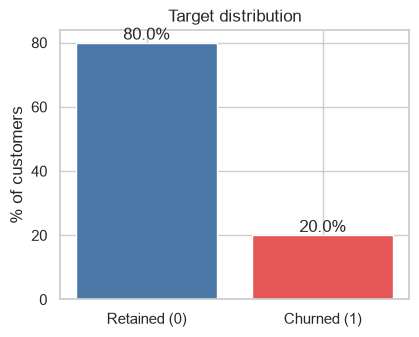

In [16]:
counts = y.value_counts().sort_index()
share = y.value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({"customers": counts, "share_%": share}))

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.bar(["Retained (0)", "Churned (1)"], share.values, color=["#4C78A8", "#E45756"])
ax.set_ylabel("% of customers"); ax.set_title("Target distribution")
for i, v in enumerate(share.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.show()

About 1 in 5 customers churns, so the classes are **imbalanced**. Accuracy alone would be misleading (predicting "nobody churns" already gives ~80%). We will judge models by **ROC-AUC** and **PR-AUC**.

### 5.2 Churn rate by category

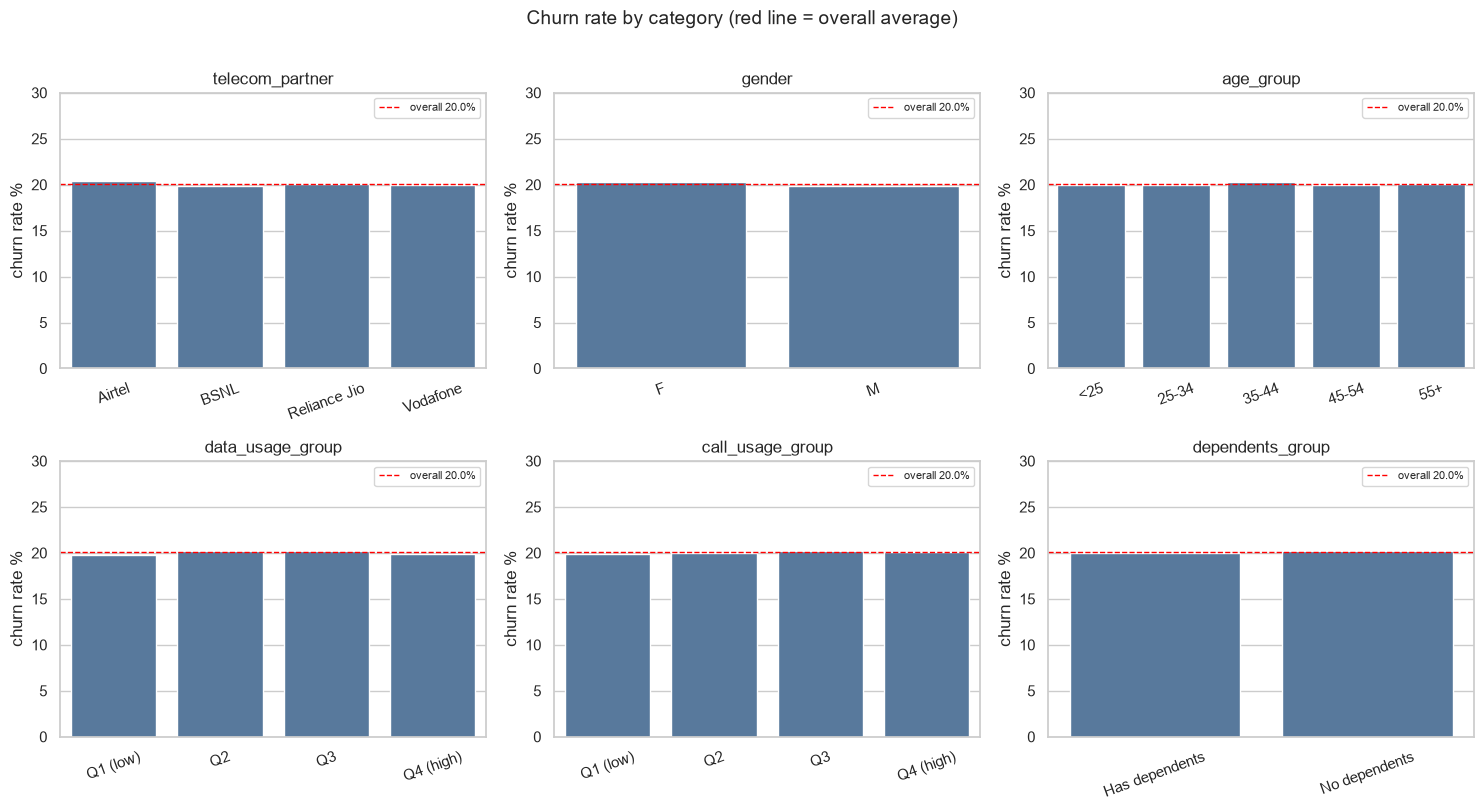

In [17]:
# EDA-only copy with human-friendly groups (NOT used for modelling)
eda = df.copy()
eda["age_group"] = pd.cut(eda["age"], bins=[0, 25, 35, 45, 55, 120], right=False,
                          labels=["<25", "25-34", "35-44", "45-54", "55+"])
for src, name in [("data_used", "data_usage_group"), ("calls_made", "call_usage_group")]:
    eda[name] = pd.qcut(eda[src].rank(method="first"), 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
eda["dependents_group"] = np.where(eda["num_dependents"] == 0, "No dependents", "Has dependents")

overall = eda[TARGET].mean() * 100
plot_cols = ["telecom_partner", "gender", "age_group", "data_usage_group", "call_usage_group", "dependents_group"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    rate = eda.groupby(col, observed=True)[TARGET].mean() * 100
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="#4C78A8")
    ax.axhline(overall, color="red", linestyle="--", linewidth=1, label=f"overall {overall:.1f}%")
    ax.set_title(col); ax.set_ylabel("churn rate %"); ax.set_xlabel("")
    ax.set_ylim(0, max(30, rate.max() * 1.25)); ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Churn rate by category (red line = overall average)", y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

In [18]:
# State-level spread (28+ states -> table instead of plot)
state_tbl = (eda.groupby("state")[TARGET].agg(customers="count", churn_rate="mean")
             .assign(churn_rate=lambda t: t["churn_rate"] * 100)
             .sort_values("churn_rate", ascending=False))
print(f"State churn rate ranges from {state_tbl.churn_rate.min():.2f}% to {state_tbl.churn_rate.max():.2f}% (overall {overall:.2f}%)")
state_tbl.head(5)

State churn rate ranges from 19.40% to 21.12% (overall 20.05%)


,customers,churn_rate
state,,
Jharkhand,8755,21.1194
Karnataka,8845,20.7123
Mizoram,8689,20.6468
Uttarakhand,8856,20.4155
Himachal Pradesh,8682,20.4100


### 5.3 Numeric features: churned vs retained

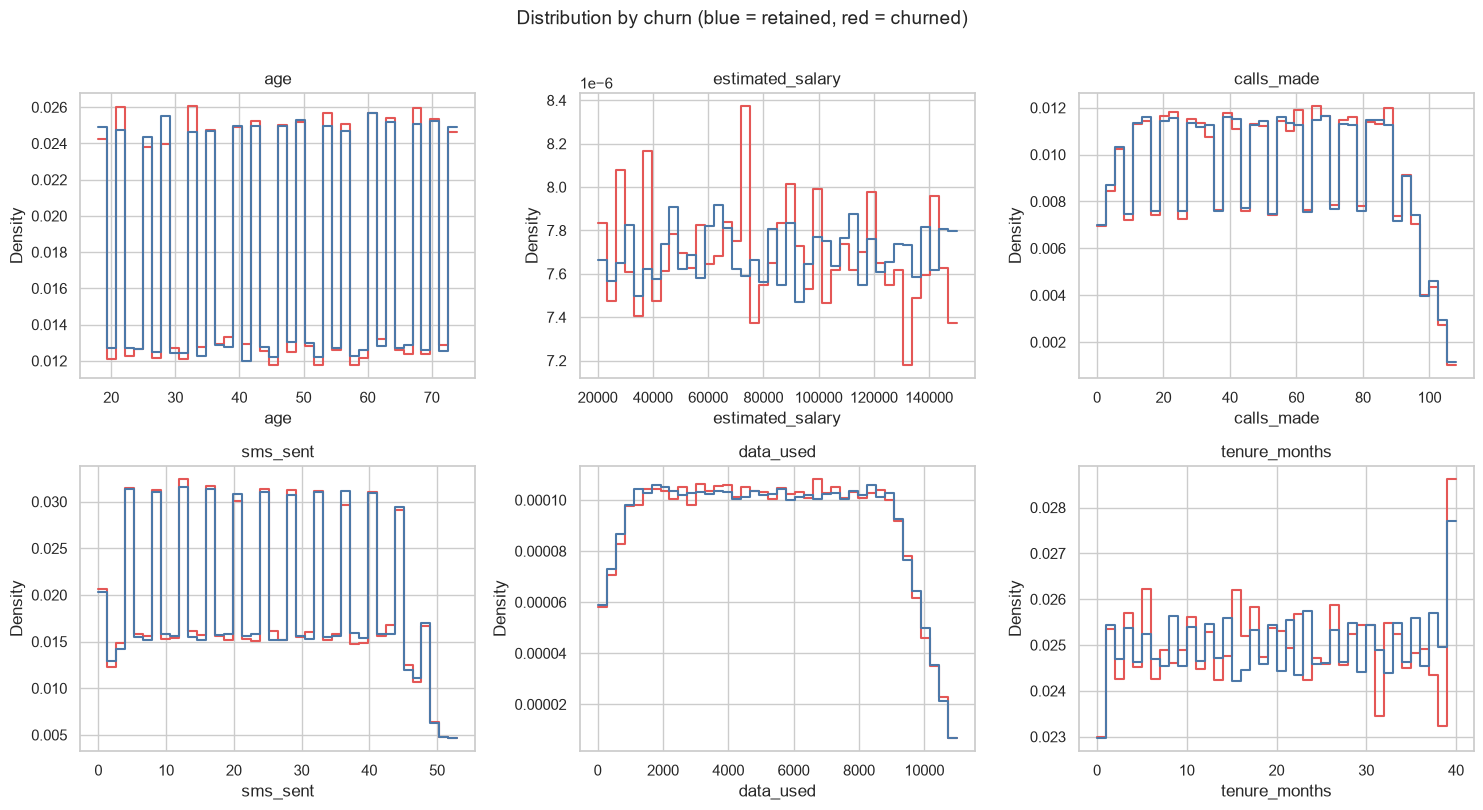

,age,estimated_salary,calls_made,sms_sent,data_used,tenure_months
churn,,,,,,
retained (median),46.0000,"85,051.0000",50.0000,25.0000,"5,111.0000",20.1000
churned (median),46.0000,"84,768.0000",51.0000,25.0000,"5,118.0000",20.0000


In [19]:
num_eda = ["age", "estimated_salary", "calls_made", "sms_sent", "data_used", "tenure_months"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_eda):
    sns.histplot(data=eda, x=col, hue=TARGET, stat="density", common_norm=False,
                 element="step", fill=False, bins=40, ax=ax, palette={0: "#4C78A8", 1: "#E45756"}, legend=False)
    ax.set_title(col)
plt.suptitle("Distribution by churn (blue = retained, red = churned)", y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

eda.groupby(TARGET)[num_eda].median().rename(index={0: "retained (median)", 1: "churned (median)"})

### 5.4 Correlation with churn

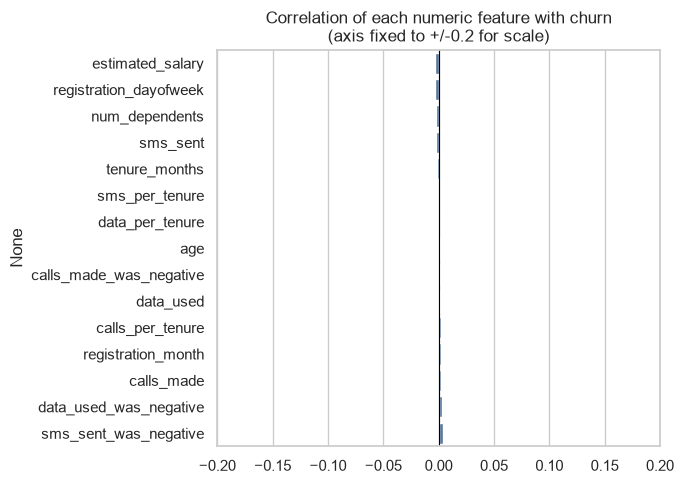

Strongest absolute correlation with churn: 0.0034


In [20]:
corr_cols = NUMERIC + [TARGET]
corr = df[corr_cols].corr()

churn_corr = corr[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=churn_corr.values, y=churn_corr.index, ax=ax, color="#4C78A8")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-0.2, 0.2)
ax.set_title("Correlation of each numeric feature with churn\n(axis fixed to +/-0.2 for scale)")
plt.tight_layout(); plt.show()

print("Strongest absolute correlation with churn:", round(churn_corr.abs().max(), 4))

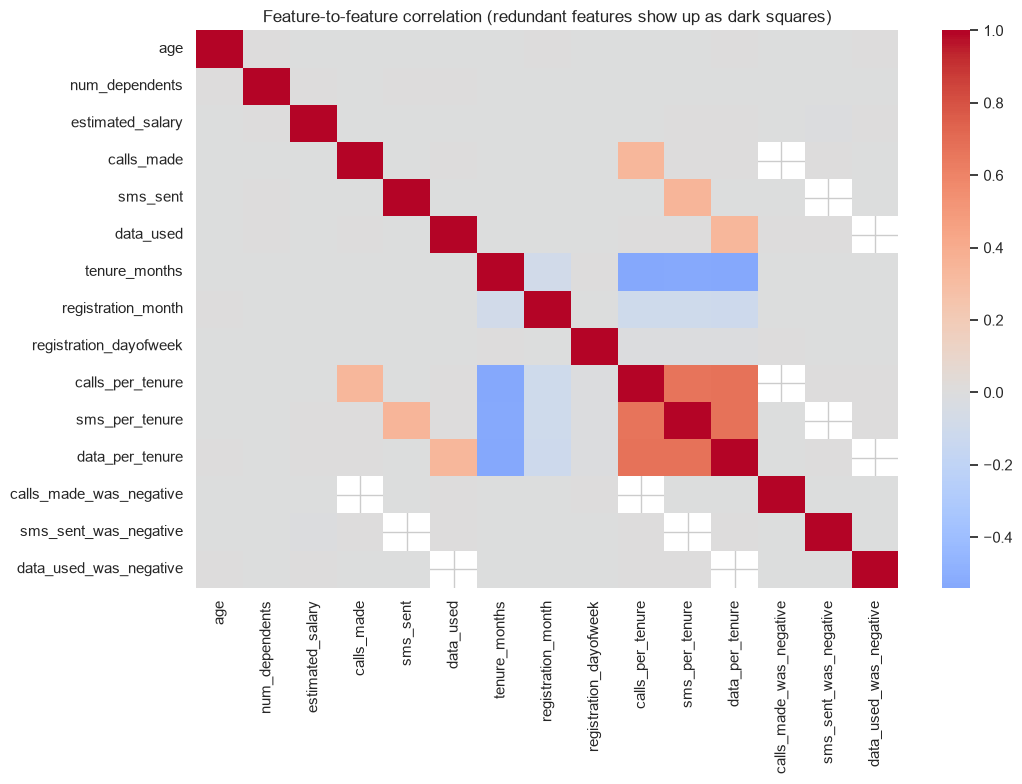

In [21]:
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(df[NUMERIC].corr(), cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Feature-to-feature correlation (redundant features show up as dark squares)")
plt.tight_layout(); plt.show()

## 6. Statistical Testing
Two questions per feature: **is the difference statistically significant?** and **is it big enough to matter?**

- Numeric features: Mann-Whitney U test. The effect size is the *probability of superiority*: 0.50 means no difference between churned and retained.
- Categorical features: Chi-square test. The effect size is Cramér's V: 0 means no association.

With ~240k rows even tiny differences can look "significant", and running many tests produces false positives by chance. So we also apply a **Benjamini-Hochberg (FDR) correction** across all tests.

In [22]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order] * n / np.arange(1, n + 1)
    adjusted = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(adjusted, 0, 1)
    return out


rows = []

# ---- Numeric: Mann-Whitney U ----
for col in ["age", "num_dependents", "estimated_salary", "calls_made", "sms_sent", "data_used", "tenure_months"]:
    a = eda.loc[eda[TARGET] == 0, col].dropna()
    b = eda.loc[eda[TARGET] == 1, col].dropna()
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    rows.append({"feature": col, "test": "Mann-Whitney U", "effect_size": u / (len(a) * len(b)),
                 "effect_meaning": "0.50 = no effect", "p_value": p})

# ---- Categorical: Chi-square + Cramer's V ----
cat_tests = ["telecom_partner", "gender", "state", "city", "partner_state",
             "age_group", "data_usage_group", "call_usage_group", "dependents_group"]
for col in cat_tests:
    table = pd.crosstab(eda[col], eda[TARGET])
    chi2, p, dof, _ = chi2_contingency(table)
    n = table.values.sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    rows.append({"feature": col, "test": "Chi-square", "effect_size": v,
                 "effect_meaning": "0 = no effect", "p_value": p})

tests = pd.DataFrame(rows)
tests["p_adjusted_FDR"]   = benjamini_hochberg(tests["p_value"])
tests["significant_raw"]  = tests["p_value"] < ALPHA
tests["significant_FDR"]  = tests["p_adjusted_FDR"] < ALPHA
tests.sort_values("p_value").reset_index(drop=True)

,feature,test,effect_size,effect_meaning,p_value,p_adjusted_FDR,significant_raw,significant_FDR
0,gender,Chi-square,0.0051,0 = no effect,0.0122,0.1952,True,False
1,estimated_salary,Mann-Whitney U,0.5024,0.50 = no effect,0.1003,0.4263,False,False
2,data_usage_group,Chi-square,0.0049,0 = no effect,0.1222,0.4263,False,False
3,city,Chi-square,0.0059,0 = no effect,0.1320,0.4263,False,False
4,telecom_partner,Chi-square,0.0048,0 = no effect,0.1332,0.4263,False,False
5,partner_state,Chi-square,0.0225,0 = no effect,0.1959,0.4498,False,False
6,num_dependents,Mann-Whitney U,0.5018,0.50 = no effect,0.2093,0.4498,False,False
7,dependents_group,Chi-square,0.0023,0 = no effect,0.2518,0.4498,False,False
8,calls_made,Mann-Whitney U,0.4983,0.50 = no effect,0.2578,0.4498,False,False
9,sms_sent,Mann-Whitney U,0.5016,0.50 = no effect,0.2811,0.4498,False,False


In [23]:
n_tests = len(tests)
print(f"Tests run                          : {n_tests}")
print(f"Expected false positives at 5%     : ~{n_tests * ALPHA:.1f}")
print(f"'Significant' before correction    : {tests.significant_raw.sum()}  -> {tests.loc[tests.significant_raw, 'feature'].tolist()}")
print(f"Significant after FDR correction   : {tests.significant_FDR.sum()}  -> {tests.loc[tests.significant_FDR, 'feature'].tolist()}")

Tests run                          : 16
Expected false positives at 5%     : ~0.8
'Significant' before correction    : 1  -> ['gender']
Significant after FDR correction   : 0  -> []


### Is the "worst" operator x state combination real, or just chance?
With 112 `partner_state` groups, the highest churn rate will always look impressive. We check with a simulation: if churn were *pure chance* at the overall rate, how extreme would the top group be?

In [24]:
base = eda[TARGET].mean()
ps = eda.groupby("partner_state")[TARGET].agg(customers="count", churn_rate="mean")
ps["z_score"] = (ps["churn_rate"] - base) / np.sqrt(base * (1 - base) / ps["customers"])

observed_max_z = ps["z_score"].abs().max()

rng = np.random.RandomState(RANDOM_STATE)
n_g = ps["customers"].values
sim_max = np.array([
    np.abs((rng.binomial(n_g, base) / n_g - base) / np.sqrt(base * (1 - base) / n_g)).max()
    for _ in range(2000)
])

print(f"Groups: {len(ps)} | largest |z| observed: {observed_max_z:.2f}")
print(f"Typical largest |z| if churn were pure chance: {np.median(sim_max):.2f} "
      f"(95th percentile {np.percentile(sim_max, 95):.2f})")
print(f"Simulated p-value (chance of a group this extreme): {(sim_max >= observed_max_z).mean():.3f}")

(ps.assign(churn_rate=lambda t: t["churn_rate"] * 100)
   .sort_values("z_score", ascending=False).head(8))

Groups: 112 | largest |z| observed: 3.70
Typical largest |z| if churn were pure chance: 2.75 (95th percentile 3.48)
Simulated p-value (chance of a group this extreme): 0.022


,customers,churn_rate,z_score
partner_state,,,
Reliance Jio_Jharkhand,2184,23.2143,3.6962
Vodafone_Madhya Pradesh,2136,22.6124,2.9605
Airtel_Himachal Pradesh,2167,22.5196,2.8741
Airtel_Mizoram,2113,22.2906,2.5751
Airtel_Assam,2113,21.7227,1.9230
Airtel_Rajasthan,2214,21.6350,1.8655
Airtel_Uttarakhand,2196,21.4936,1.6923
Vodafone_Jharkhand,2194,21.3309,1.5012


**How to read this:** if the simulated p-value is not small, the top operator x state groups are what you would expect from randomness alone. Even if it were small, the gap would only be a few percentage points, which is far too weak to predict individual customers (see the model results below).

## 7. Train / Test Split
Stratified split keeps the 80/20 churn ratio in both parts. The **test set is not touched** until final evaluation.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(pd.DataFrame({
    "train_churn_rate": [y_train.mean()],
    "test_churn_rate":  [y_test.mean()],
}))

X_train: (194842, 20) | X_test: (48711, 20)
   train_churn_rate  test_churn_rate
0            0.2005           0.2005


## 8. Preprocessing Pipelines
Everything that *learns* from data (median imputation, scaling, encoding) lives inside the pipeline, so it is fitted on training data only, including inside cross-validation.

- **Linear / tree / forest models:** median-impute + scale numerics, one-hot encode categoricals.
- **Gradient boosting:** median-impute numerics, ordinal-encode categoricals and let the model treat them as native categories.

In [27]:
def make_onehot_preprocessor():
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler())])
    return ColumnTransformer([
        ("num", numeric, NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ])


def make_native_cat_preprocessor():
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), NUMERIC),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CATEGORICAL),
    ])


# Position of categorical columns after the ColumnTransformer (numeric first, then categorical)
CAT_POSITIONS = list(range(len(NUMERIC), len(NUMERIC) + len(CATEGORICAL)))

## 9. Baselines
A model is only useful if it beats a **no-skill baseline**. Three are used:
- `most_frequent`: always predicts "no churn".
- `stratified`: predicts churn randomly at the 20% base rate.
- `always_churn`: predicts churn for everyone. Note its F1 is about 0.33 **without learning anything**, so a model with F1 near 0.3 is not impressive.

In [28]:
def evaluate(name, model, fit=True):
    if fit:
        model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    metrics = {
        "model":     name,
        "accuracy":  accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall":    recall_score(y_test, pred, zero_division=0),
        "f1":        f1_score(y_test, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_test, prob),
        "pr_auc":    average_precision_score(y_test, prob),
        "predicted_churn_%": pred.mean() * 100,
    }
    return metrics, prob, pred


results, probs, preds, fitted = [], {}, {}, {}

baselines = {
    "Baseline: most_frequent": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Baseline: stratified":    DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Baseline: always_churn":  DummyClassifier(strategy="constant", constant=1),
}
for name, model in baselines.items():
    m, p, pr = evaluate(name, model)
    results.append(m); probs[name] = p; preds[name] = pr; fitted[name] = model

pd.DataFrame(results).round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_churn_%
0,Baseline: most_frequent,0.7995,0.0000,0.0000,0.0000,0.5000,0.2005,0.0000
1,Baseline: stratified,0.6775,0.1945,0.1939,0.1942,0.4963,0.1993,19.9791
2,Baseline: always_churn,0.2005,0.2005,1.0000,0.3340,0.5000,0.2005,100.0000


## 10. Model Training and Evaluation
Four models of increasing complexity. `class_weight="balanced"` is used because, without it, Logistic Regression simply predicts "no churn" for everyone (accuracy 80%, recall 0%).

In [29]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", make_onehot_preprocessor()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("prep", make_onehot_preprocessor()),
        ("model", DecisionTreeClassifier(max_depth=8, min_samples_leaf=50,
                                         class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("prep", make_onehot_preprocessor()),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=50,
                                         class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", make_native_cat_preprocessor()),
        ("model", HistGradientBoostingClassifier(categorical_features=CAT_POSITIONS,
                                                 class_weight="balanced", early_stopping=True,
                                                 random_state=RANDOM_STATE)),
    ]),
}

for name, model in models.items():
    m, p, pr = evaluate(name, model)
    results.append(m); probs[name] = p; preds[name] = pr; fitted[name] = model
    print(f"{name:<22} ROC-AUC = {m['roc_auc']:.4f} | PR-AUC = {m['pr_auc']:.4f}")

Logistic Regression    ROC-AUC = 0.5040 | PR-AUC = 0.2032
Decision Tree          ROC-AUC = 0.4950 | PR-AUC = 0.1983
Random Forest          ROC-AUC = 0.5048 | PR-AUC = 0.2037
Gradient Boosting      ROC-AUC = 0.4994 | PR-AUC = 0.2006


### 10.1 Model comparison

In [30]:
results_df = pd.DataFrame(results).round(4).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_churn_%
0,Random Forest,0.5272,0.2024,0.4621,0.2815,0.5048,0.2037,45.7617
1,Logistic Regression,0.5206,0.2011,0.4680,0.2813,0.5040,0.2032,46.6568
2,Baseline: most_frequent,0.7995,0.0000,0.0000,0.0000,0.5000,0.2005,0.0000
3,Baseline: always_churn,0.2005,0.2005,1.0000,0.3340,0.5000,0.2005,100.0000
4,Gradient Boosting,0.5160,0.1988,0.4667,0.2788,0.4994,0.2006,47.0592
5,Baseline: stratified,0.6775,0.1945,0.1939,0.1942,0.4963,0.1993,19.9791
6,Decision Tree,0.4267,0.1986,0.6127,0.3000,0.4950,0.1983,61.8505


**How to read this table**
- `roc_auc`: 0.50 = coin flip, 1.00 = perfect. This is the main metric here.
- `pr_auc`: compare to the churn base rate (~0.20). A no-skill model scores about the base rate.
- `f1`, `precision`, `recall` depend on the decision threshold. A model that predicts churn for many customers gets high recall and F1 *without being useful* (see `always_churn`).

### 10.2 ROC and Precision-Recall curves

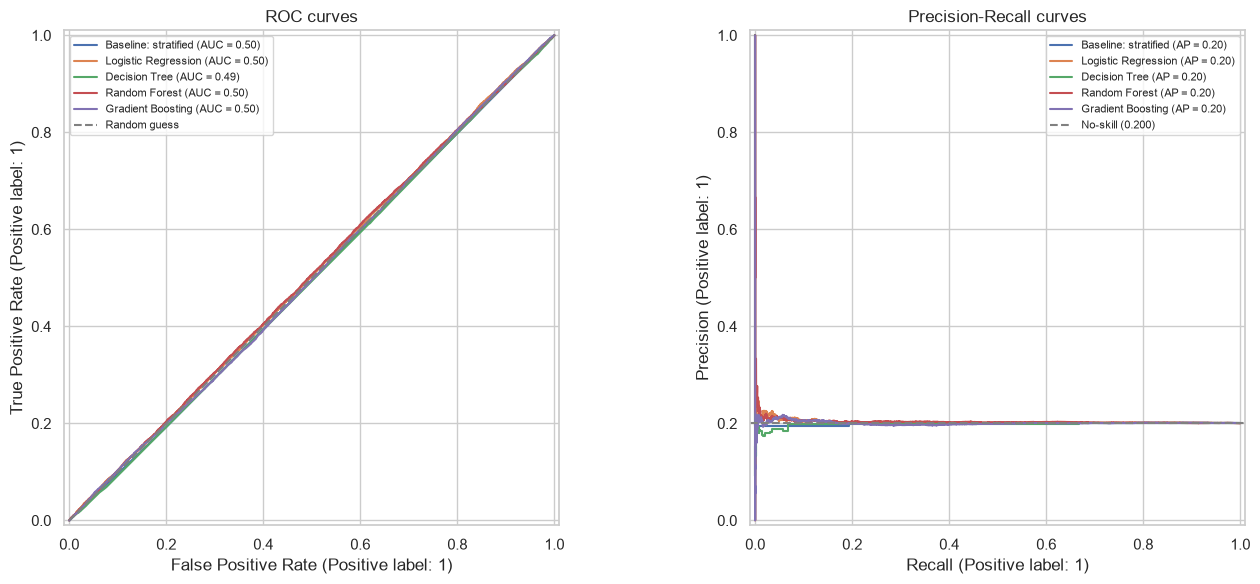

In [31]:
curve_models = ["Baseline: stratified", "Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name in curve_models:
    RocCurveDisplay.from_predictions(y_test, probs[name], name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, probs[name], name=name, ax=axes[1])

axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random guess")
axes[0].set_title("ROC curves"); axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"No-skill ({y_test.mean():.3f})")
axes[1].set_title("Precision-Recall curves"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 10.3 Confusion matrices

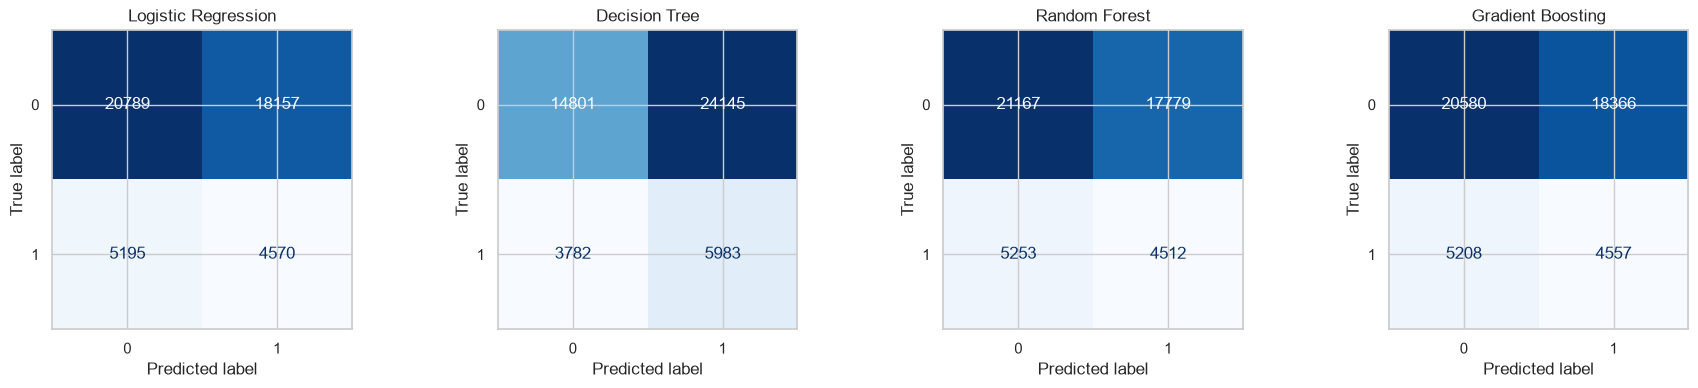

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, models.keys()):
    ConfusionMatrixDisplay.from_predictions(y_test, preds[name], ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout(); plt.show()

## 11. Cross-Validation
One 80/20 split can be lucky or unlucky. 5-fold stratified CV (on the **training set only**) checks whether the result is stable.

In [33]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_rows, cv_scores = [], {}
for name, model in models.items():
    out = cross_validate(clone(model), X_train, y_train, cv=cv,
                         scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"})
    cv_scores[name] = out["test_roc_auc"]
    cv_rows.append({
        "model": name,
        "cv_roc_auc_mean": out["test_roc_auc"].mean(),
        "cv_roc_auc_std":  out["test_roc_auc"].std(),
        "cv_pr_auc_mean":  out["test_pr_auc"].mean(),
    })

cv_df = pd.DataFrame(cv_rows).round(4).sort_values("cv_roc_auc_mean", ascending=False).reset_index(drop=True)
cv_df

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean
0,Decision Tree,0.5014,0.0032,0.2010
1,Random Forest,0.5011,0.0038,0.2013
2,Logistic Regression,0.5000,0.0026,0.2010
3,Gradient Boosting,0.4985,0.0011,0.2002


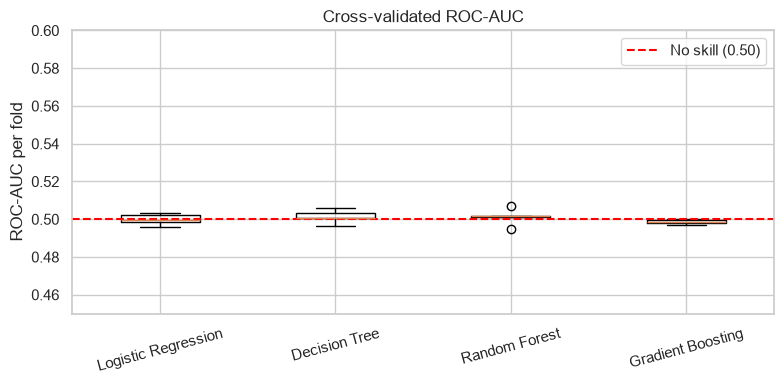

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(list(cv_scores.values()))
ax.set_xticklabels(list(cv_scores.keys()))
ax.axhline(0.5, color="red", linestyle="--", label="No skill (0.50)")
ax.set_ylim(0.45, 0.60); ax.set_ylabel("ROC-AUC per fold")
ax.set_title("Cross-validated ROC-AUC"); ax.legend()
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 12. Hyperparameter Tuning
Gradient Boosting is tuned because it is the fastest strong model. The goal is to rule out "the model just wasn't tuned". The search runs on a sample of the training data for speed, then the best settings are refit on the full training set.

In [35]:
if len(X_train) > TUNING_SAMPLE:
    X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=TUNING_SAMPLE,
                                            stratify=y_train, random_state=RANDOM_STATE)
else:
    X_tune, y_tune = X_train, y_train

param_distributions = {
    "model__learning_rate":     [0.03, 0.05, 0.1],
    "model__max_depth":         [None, 3, 5, 8],
    "model__max_leaf_nodes":    [15, 31, 63],
    "model__min_samples_leaf":  [20, 50, 100],
    "model__l2_regularization": [0.0, 1.0, 10.0],
}

search = RandomizedSearchCV(
    clone(models["Gradient Boosting"]),
    param_distributions=param_distributions,
    n_iter=10, scoring="roc_auc", cv=3,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_tune, y_tune)

print("Best params    :", search.best_params_)
print("Best CV ROC-AUC:", round(search.best_score_, 4))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params    : {'model__min_samples_leaf': 100, 'model__max_leaf_nodes': 15, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__l2_regularization': 1.0}
Best CV ROC-AUC: 0.4979


In [36]:
tuned = clone(models["Gradient Boosting"]).set_params(**search.best_params_)
m, p, pr = evaluate("Gradient Boosting (tuned)", tuned)
results.append(m); probs[m["model"]] = p; preds[m["model"]] = pr; fitted[m["model"]] = tuned

print(f"Tuned ROC-AUC on test : {m['roc_auc']:.4f}")
print(f"Untuned ROC-AUC on test: {roc_auc_score(y_test, probs['Gradient Boosting']):.4f}")

Tuned ROC-AUC on test : 0.5036
Untuned ROC-AUC on test: 0.4994


### Final comparison (all models, test set)

In [37]:
final_df = pd.DataFrame(results).round(4).sort_values("roc_auc", ascending=False).reset_index(drop=True)
final_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_churn_%
0,Random Forest,0.5272,0.2024,0.4621,0.2815,0.5048,0.2037,45.7617
1,Logistic Regression,0.5206,0.2011,0.4680,0.2813,0.5040,0.2032,46.6568
2,Gradient Boosting (tuned),0.5063,0.2020,0.4958,0.2870,0.5036,0.2027,49.2045
3,Baseline: most_frequent,0.7995,0.0000,0.0000,0.0000,0.5000,0.2005,0.0000
4,Baseline: always_churn,0.2005,0.2005,1.0000,0.3340,0.5000,0.2005,100.0000
5,Gradient Boosting,0.5160,0.1988,0.4667,0.2788,0.4994,0.2006,47.0592
6,Baseline: stratified,0.6775,0.1945,0.1939,0.1942,0.4963,0.1993,19.9791
7,Decision Tree,0.4267,0.1986,0.6127,0.3000,0.4950,0.1983,61.8505


## 13. Sanity Checks: Is There Any Real Signal?
Three quick tests to decide whether the ~0.50 result is a *modelling* problem or a *data* problem.

### 13.1 Shuffled-label test

In [38]:
# Train the same model on randomly shuffled labels. This is what "no signal at all" looks like.
rng = np.random.RandomState(RANDOM_STATE)
y_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)

shuffle_model = clone(models["Logistic Regression"]).fit(X_train, y_shuffled)
auc_shuffled = roc_auc_score(y_test, shuffle_model.predict_proba(X_test)[:, 1])
auc_real = roc_auc_score(y_test, probs["Logistic Regression"])

print(f"Logistic Regression, real labels    : ROC-AUC = {auc_real:.4f}")
print(f"Logistic Regression, shuffled labels: ROC-AUC = {auc_shuffled:.4f}")
print("\nIf these two are about the same, the model has learned nothing from the real labels.")

Logistic Regression, real labels    : ROC-AUC = 0.5040
Logistic Regression, shuffled labels: ROC-AUC = 0.4951

If these two are about the same, the model has learned nothing from the real labels.


### 13.2 Confidence interval for the best model's test ROC-AUC

In [39]:
model_names = ["Logistic Regression", "Decision Tree", "Random Forest",
               "Gradient Boosting", "Gradient Boosting (tuned)"]
best_name = max(model_names, key=lambda n: roc_auc_score(y_test, probs[n]))

yt, pp = y_test.values, probs[best_name]
rng = np.random.RandomState(RANDOM_STATE)
boot = []
for _ in range(200):
    idx = rng.randint(0, len(yt), len(yt))
    boot.append(roc_auc_score(yt[idx], pp[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"Best model on test: {best_name}")
print(f"ROC-AUC = {roc_auc_score(yt, pp):.4f}  (95% bootstrap CI: {lo:.4f} to {hi:.4f})")
print("If the interval contains 0.50, the model is statistically indistinguishable from guessing.")

Best model on test: Random Forest
ROC-AUC = 0.5048  (95% bootstrap CI: 0.4984 to 0.5117)
If the interval contains 0.50, the model is statistically indistinguishable from guessing.


### 13.3 Permutation importance

Random-forest built-in importance is biased toward continuous columns (they offer more split points), so it ranks noise columns like `estimated_salary` high even when they carry no signal. **Permutation importance** on the test set measures how much ROC-AUC actually drops when a feature is shuffled. Values near 0 mean the feature is not helping.

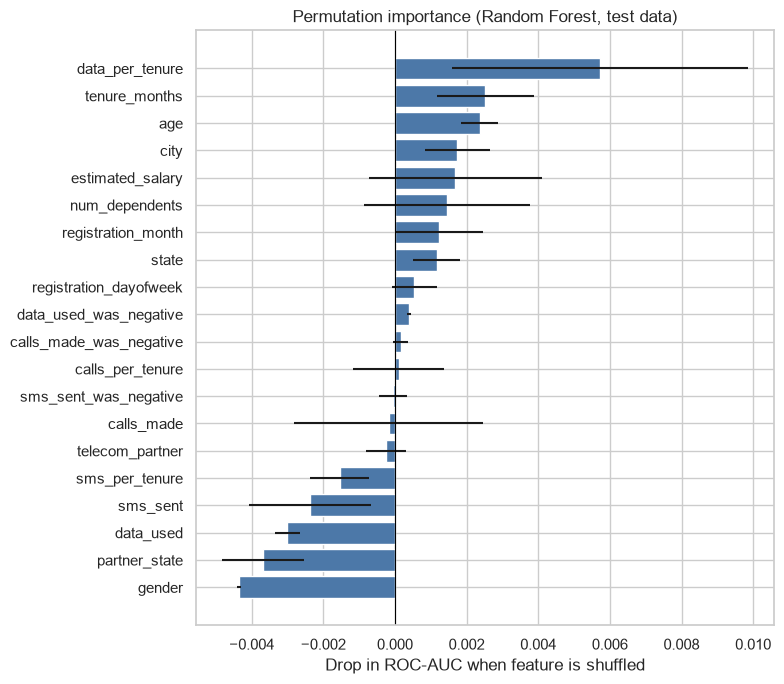

Largest importance: 0.00572 (a real driver would be clearly > 0.01)


In [40]:
X_perm = X_test.sample(n=min(10_000, len(X_test)), random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]

perm = permutation_importance(fitted["Random Forest"], X_perm, y_perm,
                              scoring="roc_auc", n_repeats=3,
                              random_state=RANDOM_STATE, n_jobs=1)

perm_df = (pd.DataFrame({"feature": X_perm.columns,
                         "importance_mean": perm.importances_mean,
                         "importance_std":  perm.importances_std})
           .sort_values("importance_mean", ascending=True))

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(perm_df["feature"], perm_df["importance_mean"], xerr=perm_df["importance_std"], color="#4C78A8")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Drop in ROC-AUC when feature is shuffled")
ax.set_title("Permutation importance (Random Forest, test data)")
plt.tight_layout(); plt.show()

print("Largest importance:", round(perm_df["importance_mean"].max(), 5), "(a real driver would be clearly > 0.01)")

## 14. Conclusion and Next Steps

In [41]:
best_cv = cv_df["cv_roc_auc_mean"].max()
best_test = final_df.loc[~final_df["model"].str.startswith("Baseline"), "roc_auc"].max()

print(f"Best cross-validated ROC-AUC : {best_cv:.4f}")
print(f"Best test ROC-AUC            : {best_test:.4f}")
print(f"Shuffled-label ROC-AUC       : {auc_shuffled:.4f}")
print()
if best_cv < 0.52:
    print("VERDICT: No usable predictive signal. Models perform like random guessing.")
    print("         The limitation is the DATA, not the algorithm or the tuning.")
elif best_cv < 0.60:
    print("VERDICT: Weak signal. Some structure exists but it is not reliable for individual predictions.")
else:
    print("VERDICT: Meaningful signal found. Continue with feature work and threshold selection.")

Best cross-validated ROC-AUC : 0.5014
Best test ROC-AUC            : 0.5048
Shuffled-label ROC-AUC       : 0.4951

VERDICT: No usable predictive signal. Models perform like random guessing.
         The limitation is the DATA, not the algorithm or the tuning.


### What we did
1. Audited and cleaned the raw data (types, negative usage values with flags, location consistency).
2. Engineered leakage-free features (account age, usage intensity, operator x state).
3. Ran statistical tests with multiple-testing correction and a simulation for the operator x state groups.
4. Trained 4 models against 3 baselines, with cross-validation, tuning, shuffled-label and bootstrap checks.

### What we found (full-data run)
- Best ROC-AUC across all models is **about 0.50**, identical to random guessing. Cross-validation, tuning and a stronger model (gradient boosting) do not change this.
- Churned and retained customers look the same on every feature (medians, means, churn rates by group).
- Location columns are internally inconsistent, so they cannot carry real geographic information.
- The small differences that appear (e.g. gender, ~0.4 percentage points) are not significant after multiple-testing correction and are far too small to be useful.

### Business interpretation
Demographics, location and basic usage volume **do not explain churn in this dataset**. Building more complex models on the same columns will not help.

### Recommended next steps
1. **Collect drivers of churn that are missing here:** contract type, monthly charges and plan, complaints and support tickets, network quality and call drops, competitor offers, payment history.
2. **Get a true churn date** to compute real tenure and to enable time-based validation.
3. **Verify the data source.** If the location columns are randomly generated, ask whether the target was generated the same way.
4. **To practise the same workflow on real data,** try the public *IBM Telco Customer Churn* dataset (~7,000 rows with contract, charges and tenure). Change `DATA_PATH`, `TARGET` and the feature lists, and the notebook will run as-is.

### Limitations
- `tenure_months` is measured up to the last date in the file, not up to the churn date.
- Only ~20% of customers churn, so metrics on small groups are noisy.
- No cost of a missed churner vs. a wasted retention offer was provided, so no decision threshold was optimised.

In [44]:
import os
import joblib
from IPython.display import display

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Best real model on the test set (baselines excluded)
model_names = ["Logistic Regression", "Decision Tree", "Random Forest",
               "Gradient Boosting", "Gradient Boosting (tuned)"]
best_name = max(model_names, key=lambda n: roc_auc_score(y_test, probs[n]))
print("Best model:", best_name)

# Prediction for every test customer
test_predictions = pd.DataFrame({
    "customer_id":                 df.loc[X_test.index, "customer_id"].values,
    "actual_churn":                y_test.values,
    "predicted_churn":             preds[best_name],
    "churn_probability_demo_only":  probs[best_name].round(4),
    "model":                       best_name,
}).sort_values("customer_id").reset_index(drop=True)

# Operator x state table
partner_state_table = (ps.assign(churn_rate_pct=ps["churn_rate"] * 100)
                         .drop(columns="churn_rate")
                         .sort_values("z_score", ascending=False)
                         .reset_index())

outputs = {
    "01_telecom_churn_cleaned.csv":    df,
    "02_model_comparison.csv":         final_df,
    "03_cross_validation_results.csv": cv_df,
    "04_statistical_tests.csv":        tests.sort_values("p_value"),
    "05_partner_state_churn.csv":      partner_state_table,
    "06_permutation_importance.csv":   perm_df.sort_values("importance_mean", ascending=False),
    "07_test_predictions.csv":         test_predictions,
}

# Save all CSV files
summary = []
for fname, frame in outputs.items():
    path = os.path.join(OUT_DIR, fname)
    frame.to_csv(path, index=False)
    summary.append({"file": fname, "rows": len(frame), "columns": frame.shape[1],
                    "size_KB": round(os.path.getsize(path) / 1024, 1)})

# Save the model
model_path = os.path.join(OUT_DIR, "churn_model.joblib")
joblib.dump(fitted[best_name], model_path)
summary.append({"file": "churn_model.joblib", "rows": None, "columns": None,
                "size_KB": round(os.path.getsize(model_path) / 1024, 1)})

print("\nSaved files:")
display(pd.DataFrame(summary))

Best model: Random Forest

Saved files:


,file,rows,columns,size_KB
0,01_telecom_churn_cleaned.csv,"243,553.0000",25.0000,"40,707.6000"
1,02_model_comparison.csv,8.0000,8.0000,0.6000
2,03_cross_validation_results.csv,4.0000,4.0000,0.2000
3,04_statistical_tests.csv,16.0000,8.0000,1.8000
4,05_partner_state_churn.csv,112.0000,4.0000,6.9000
5,06_permutation_importance.csv,20.0000,3.0000,1.2000
6,07_test_predictions.csv,"48,711.0000",5.0000,"1,542.6000"
7,churn_model.joblib,NaN,NaN,"5,874.0000"


In [45]:
for fname in outputs:
    saved = pd.read_csv(os.path.join(OUT_DIR, fname))
    print("=" * 90)
    print(f"{fname}  |  shape: {saved.shape}")
    print("=" * 90)
    display(saved.head(10))

01_telecom_churn_cleaned.csv  |  shape: (243553, 25)


,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,calls_made_was_negative,sms_sent_was_negative,data_used_was_negative,postal_region,tenure_months,registration_month,registration_dayofweek,calls_per_tenure,sms_per_tenure,data_per_tenure,partner_state
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44.0000,45.0000,NaN,0,0,0,1,7,40.0000,1,2,1.0732,1.0976,NaN,Reliance Jio_Karnataka
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62.0000,39.0000,"5,973.0000",0,0,0,0,1,40.0000,1,2,1.5122,0.9512,145.6829,Reliance Jio_Mizoram
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49.0000,24.0000,193.0000,1,0,0,0,4,40.0000,1,2,1.1951,0.5854,4.7073,Vodafone_Arunachal Pradesh
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80.0000,25.0000,"9,377.0000",1,0,0,0,5,40.0000,1,2,1.9512,0.6098,228.7073,BSNL_Tamil Nadu
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78.0000,15.0000,"1,393.0000",0,0,0,0,7,40.0000,1,2,1.9024,0.3659,33.9756,BSNL_Tripura
5,6,Vodafone,M,36,Uttarakhand,Chennai,120612,2020-01-01,1,73452,91.0000,24.0000,"8,109.0000",0,0,0,0,1,40.0000,1,2,2.2195,0.5854,197.7805,Vodafone_Uttarakhand
6,7,BSNL,F,60,Karnataka,Delhi,609616,2020-01-01,1,110035,36.0000,13.0000,"8,512.0000",0,0,0,0,6,40.0000,1,2,0.8780,0.3171,207.6098,BSNL_Karnataka
7,8,BSNL,M,46,Arunachal Pradesh,Kolkata,866786,2020-01-01,4,104541,87.0000,40.0000,"2,245.0000",1,0,0,0,8,40.0000,1,2,2.1220,0.9756,54.7561,BSNL_Arunachal Pradesh
8,9,Reliance Jio,F,53,Himachal Pradesh,Mumbai,765257,2020-01-01,2,79439,34.0000,12.0000,"10,039.0000",0,0,0,0,7,40.0000,1,2,0.8293,0.2927,244.8537,Reliance Jio_Himachal Pradesh
9,10,BSNL,F,57,Rajasthan,Mumbai,506308,2020-01-01,0,126422,61.0000,33.0000,567.0000,0,0,0,0,5,40.0000,1,2,1.4878,0.8049,13.8293,BSNL_Rajasthan


02_model_comparison.csv  |  shape: (8, 8)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_churn_%
0,Random Forest,0.5272,0.2024,0.4621,0.2815,0.5048,0.2037,45.7617
1,Logistic Regression,0.5206,0.2011,0.4680,0.2813,0.5040,0.2032,46.6568
2,Gradient Boosting (tuned),0.5063,0.2020,0.4958,0.2870,0.5036,0.2027,49.2045
3,Baseline: most_frequent,0.7995,0.0000,0.0000,0.0000,0.5000,0.2005,0.0000
4,Baseline: always_churn,0.2005,0.2005,1.0000,0.3340,0.5000,0.2005,100.0000
5,Gradient Boosting,0.5160,0.1988,0.4667,0.2788,0.4994,0.2006,47.0592
6,Baseline: stratified,0.6775,0.1945,0.1939,0.1942,0.4963,0.1993,19.9791
7,Decision Tree,0.4267,0.1986,0.6127,0.3000,0.4950,0.1983,61.8505


03_cross_validation_results.csv  |  shape: (4, 4)


...

,partner_state,customers,z_score,churn_rate_pct
0,Reliance Jio_Jharkhand,2184,3.6962,23.2143
1,Vodafone_Madhya Pradesh,2136,2.9605,22.6124
2,Airtel_Himachal Pradesh,2167,2.8741,22.5196
3,Airtel_Mizoram,2113,2.5751,22.2906
4,Airtel_Assam,2113,1.9230,21.7227
5,Airtel_Rajasthan,2214,1.8655,21.6350
6,Airtel_Uttarakhand,2196,1.6923,21.4936
7,Vodafone_Jharkhand,2194,1.5012,21.3309
8,Reliance Jio_Manipur,2130,1.4062,21.2676
9,Reliance Jio_Uttar Pradesh,2194,1.3945,21.2397


06_permutation_importance.csv  |  shape: (20, 3)


,feature,importance_mean,importance_std
0,data_per_tenure,0.0057,0.0041
1,tenure_months,0.0025,0.0014
2,age,0.0024,0.0005
3,city,0.0017,0.0009
4,estimated_salary,0.0017,0.0024
5,num_dependents,0.0015,0.0023
6,registration_month,0.0012,0.0012
7,state,0.0012,0.0007
8,registration_dayofweek,0.0005,0.0006
9,data_used_was_negative,0.0004,0.0001


07_test_predictions.csv  |  shape: (48711, 5)


,customer_id,actual_churn,predicted_churn,churn_probability_demo_only,model
0,9,0,0,0.4931,Random Forest
1,11,1,0,0.4753,Random Forest
2,15,0,0,0.4895,Random Forest
3,17,1,0,0.4850,Random Forest
4,21,0,0,0.4764,Random Forest
5,22,0,0,0.4862,Random Forest
6,24,0,0,0.4966,Random Forest
7,34,0,0,0.4814,Random Forest
8,36,0,0,0.4850,Random Forest
9,46,0,0,0.4927,Random Forest


In [46]:
loaded_model = joblib.load(os.path.join(OUT_DIR, "churn_model.joblib"))
sample = X_test.head(5)

check = pd.DataFrame({
    "customer_id": df.loc[sample.index, "customer_id"].values,
    "predicted_churn": loaded_model.predict(sample),
    "churn_probability_demo_only": loaded_model.predict_proba(sample)[:, 1].round(4),
})
check

,customer_id,predicted_churn,churn_probability_demo_only
0,215745,1,0.5095
1,218579,0,0.4934
2,144658,1,0.5079
3,72822,0,0.4982
4,48873,1,0.5049


In [47]:
import os, sys, shutil, subprocess
from pathlib import Path

# 1) Find the outputs folder
src = Path("outputs")
if not src.exists():
    raise FileNotFoundError(
        "The 'outputs' folder was not found. Run the Section 15 'Save Outputs' cell first, "
        f"and make sure this notebook is in the same folder: {Path.cwd()}"
    )

# 2) Find the Downloads folder (also checks the OneDrive location)
candidates = [Path.home() / "Downloads", Path.home() / "OneDrive" / "Downloads"]
downloads = next((p for p in candidates if p.exists()), candidates[0])
downloads.mkdir(parents=True, exist_ok=True)

# 3) Copy all files individually
dest_folder = downloads / "churn_outputs"
shutil.copytree(src, dest_folder, dirs_exist_ok=True)

# 4) Also create a ZIP file
zip_path = shutil.make_archive(str(downloads / "churn_outputs"), "zip", src)

# 5) Show what was copied
print("Files copied to:", dest_folder, "\n")
for f in sorted(dest_folder.iterdir()):
    print(f"  {f.name:<40} {f.stat().st_size / 1024 / 1024:8.2f} MB")
print("\nZIP file:", zip_path)

# 6) Open the folder
if sys.platform.startswith("win"):
    os.startfile(dest_folder)
elif sys.platform == "darwin":
    subprocess.run(["open", str(dest_folder)])
else:
    subprocess.run(["xdg-open", str(dest_folder)])

Files copied to: C:\Users\SASWAT\Downloads\churn_outputs 

  01_telecom_churn_cleaned.csv                39.75 MB
  02_model_comparison.csv                      0.00 MB
  03_cross_validation_results.csv              0.00 MB
  04_statistical_tests.csv                     0.00 MB
  05_partner_state_churn.csv                   0.01 MB
  06_permutation_importance.csv                0.00 MB
  07_test_predictions.csv                      1.51 MB
  churn_model.joblib                           5.74 MB

ZIP file: C:\Users\SASWAT\Downloads\churn_outputs.zip


In [48]:
import joblib

model = joblib.load("outputs/churn_model.joblib")
prep  = model.named_steps["prep"]
rf    = model.named_steps["model"]

print("Model type       :", type(rf).__name__)
print("Number of trees  :", len(rf.estimators_))
print("Max depth        :", rf.max_depth)
print("Input features   :", list(prep.feature_names_in_))
print("Features after preprocessing:", len(prep.get_feature_names_out()))

Model type       : RandomForestClassifier
Number of trees  : 200
Max depth        : 12
Input features   : ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'tenure_months', 'registration_month', 'registration_dayofweek', 'calls_per_tenure', 'sms_per_tenure', 'data_per_tenure', 'calls_made_was_negative', 'sms_sent_was_negative', 'data_used_was_negative', 'telecom_partner', 'gender', 'state', 'city', 'partner_state']
Features after preprocessing: 167
